**Másteres Universitarios en Ciencia de Datos y en Sistemas Interativos Inteligentes, UAM**
## **Procesamiento del Lenguaje Natural**
# **Práctica de laboratorio 3: Word embeddings**

---

_Aviso_: algunas de las explicaciones y ejemplos de este notebook proceden de [Documentación de GenSim en NLTK](https://www.nltk.org/howto/gensim.html)

------------------------------------------
### Pareja número: equipo 14
### Miembros: Xiaoyong Wang， Chenghu Yang
------------------------------------------

Antes de comenzar a trabajar, debemos configurar el entorno: 
- NLTK
- GenSim: permite trabajar con embeddings de palabras empleando Word2Vec, FastText y Doc2Vec.

Si no lo tenemos ya instalado, instalemos NLTK:

!pip install nltk

Ahora instalemos GenSim para poder trabajar con Word2Vec:

!pip install gensim

In [24]:
from nltk.test.gensim_fixt import setup_module
setup_module() # Puede que antes tengamos que ejecutar: !pip install pytest

Si no está ya instalado, descarguemos el corpus Brown de entre los disponibles en NLTK. Este es un corpus en inglés creado en 1961 en la Universidad de Brown. Cuenta con un millón de palabras con texto de 500 fuentes (noticias, editorial, etc.)

In [25]:
import nltk
nltk.download('brown')

[nltk_data] Downloading package brown to
[nltk_data]     /Users/gaelscomputer/nltk_data...
[nltk_data]   Package brown is already up-to-date!


True

Para probar, nos bastará con tomar 10000 oraciones del corpus.

In [26]:
from nltk.corpus import brown
train_set = brown.sents()[:10000]

Entrenamos el modelo empleando el Word2Vec de GenSim:

In [27]:
import gensim
model = gensim.models.Word2Vec(train_set)

Si se usa un corpus muy grande, puede llevar mucho tiempo entrenarlo. Lo más cómodo en esos casos es guardarlo y volver a cargarlo:
model.save('brown.embedding') # para guardarlo
model = gensim.models.Word2Vec.load('brown.embedding') # para recuperarlo

Veamos cuántas palabras contiene el modelo:

In [28]:
model.corpus_total_words

219770

¿Cuáles son las 100 palabras más frecuentes?

In [29]:
model.wv.index_to_key[:100]

['the',
 ',',
 '.',
 'of',
 'and',
 'to',
 'a',
 'in',
 'is',
 'that',
 'for',
 '``',
 'The',
 "''",
 'was',
 'as',
 'on',
 'with',
 'be',
 'it',
 'by',
 'at',
 'he',
 'his',
 'are',
 ';',
 'not',
 'has',
 'from',
 'have',
 'this',
 'will',
 'an',
 '--',
 'which',
 'who',
 '?',
 'or',
 'but',
 'had',
 'would',
 'I',
 'one',
 'said',
 'were',
 'they',
 'all',
 'been',
 'their',
 'more',
 'its',
 ':',
 ')',
 '(',
 'He',
 'Mr.',
 'we',
 'than',
 'out',
 'It',
 'In',
 'up',
 'But',
 'there',
 'other',
 'when',
 'can',
 'no',
 'about',
 'only',
 'first',
 'new',
 'him',
 'A',
 'into',
 'so',
 'last',
 'Mrs.',
 'two',
 'some',
 'them',
 'what',
 'time',
 'her',
 'do',
 'any',
 'our',
 'man',
 'most',
 'also',
 'years',
 'could',
 'over',
 'year',
 'may',
 'New',
 'made',
 'if',
 'you',
 'American']

Una vez entrenado, el modelo contendrá la lista de palabras en el vocabulario del corpus procesado, junto con el embedding correspondiente para cada palabra.

Puede obtenese el embedding de una palabra accediendo al diccionario `wv` (word vector) que tiene el modelo.

In [30]:
model.wv['university']

array([-0.03750319, -0.02959616,  0.04599154, -0.12272982, -0.01197136,
       -0.3793993 ,  0.12916587,  0.39833894, -0.00201602, -0.29719448,
       -0.05841827, -0.29607525, -0.15678692,  0.25538042,  0.01256854,
       -0.06038437,  0.05083279, -0.19896857,  0.04808596, -0.30425495,
        0.08814231,  0.15719762,  0.37236765, -0.20821287,  0.02570616,
       -0.04859591, -0.14490612,  0.00425698, -0.1571585 , -0.00573836,
        0.1296994 , -0.07611104,  0.08254738, -0.20089027, -0.12299511,
        0.12014291,  0.08241928, -0.1638934 , -0.24469118, -0.14255056,
        0.10263608, -0.14743869, -0.2026557 ,  0.01358637,  0.07976505,
       -0.11572243, -0.25373086, -0.02528313,  0.15249746,  0.08876397,
       -0.0068952 , -0.20292592,  0.06702093,  0.00181673,  0.00871016,
        0.12619334,  0.188595  , -0.11614736, -0.16958162,  0.03920936,
        0.00408047,  0.12500912,  0.10471971,  0.07070493, -0.14659548,
        0.3198743 , -0.08598574,  0.2229476 , -0.14873162,  0.03

y para calcular la similitud empleando la distancia coseno entre palabras:

In [31]:
model.wv.similarity('university','school')

0.99381816

Usando un modelo preentrenado. Podemos descargarlo, o emplear uno de los que tiene nltk:

In [32]:
nltk.download('word2vec_sample')

[nltk_data] Downloading package word2vec_sample to
[nltk_data]     /Users/gaelscomputer/nltk_data...
[nltk_data]   Package word2vec_sample is already up-to-date!


True

Ahora podemos cargarlo:

In [33]:
from nltk.data import find

# fichero con los vectores en formato texto
word2vec_sample = str(find('models/word2vec_sample/pruned.word2vec.txt'))
model = gensim.models.KeyedVectors.load_word2vec_format(word2vec_sample, binary=False)

Veamos cuáles son las 3 palabras más cercanas a 'university':

In [34]:
model.most_similar(positive=['university'], topn = 3)

[('universities', 0.7003918290138245),
 ('faculty', 0.6780906915664673),
 ('undergraduate', 0.6587096452713013)]

Obtenemos el vector de una palabra. Esta vez accesible directamente desde el modelo.

In [35]:
model['queen']

array([ 0.00173332, -0.0474043 , -0.022896  ,  0.0407935 ,  0.0435346 ,
       -0.0293455 , -0.0235409 , -0.0715902 , -0.0651406 ,  0.0183813 ,
       -0.0249921 , -0.125767  ,  0.0343439 , -0.00026957,  0.043857  ,
        0.0372462 ,  0.0240246 , -0.015479  ,  0.0217673 ,  0.0311192 ,
        0.0628833 ,  0.045147  , -0.0780398 , -0.0391811 ,  0.021606  ,
       -0.0175751 , -0.101903  ,  0.030313  ,  0.0622383 , -0.0551438 ,
       -0.0515965 , -0.0432121 , -0.0272494 ,  0.0703003 , -0.117382  ,
       -0.0435346 ,  0.0317641 ,  0.0870691 , -0.0312804 ,  0.0606259 ,
        0.0353114 , -0.137376  ,  0.089004  , -0.00915032,  0.0580461 ,
       -0.0372462 , -0.00136046,  0.0480493 ,  0.0515965 ,  0.0883591 ,
       -0.00592554,  0.0325703 ,  0.0174944 , -0.0103193 , -0.0538539 ,
       -0.0191875 , -0.113512  , -0.0570787 ,  0.03773   , -0.0298292 ,
        0.044502  ,  0.0922288 , -0.0164464 ,  0.0428896 ,  0.0580461 ,
       -0.0732026 , -0.0039302 ,  0.0464369 , -0.059981  ,  0.03

Juguemos un poco...

¿cuál es la palabra que no encaja en una lista dada?

In [36]:
model.doesnt_match(['breakfast', 'cereal', 'dinner', 'lunch'])

'cereal'

¿qué vector sale si hacemos `'woman'+'king'-'man'`?

In [37]:
model.most_similar(positive=['woman','king'], negative=['man'], topn = 1)

[('queen', 0.7118193507194519)]

¿y qué saldrá de la operación `man + daughter - woman`?

In [38]:
model.most_similar(positive=['man', 'daughter'], negative=['woman'], topn=1)

[('son', 0.8490632772445679)]

Ojo, lo que nos devuelve es el vector más próximo. Si, por ejemplo, queremos sacar los 3 vectores más próximos:

In [39]:
model.most_similar(positive=['woman','king'], negative=['man'], topn = 3)

[('queen', 0.7118193507194519),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431011199951)]

Podemos explorar más ejemplos para obtener analogías semánticas menos evidentes.

In [40]:
analogias = [
    (['Paris','Japan'], ['France']),
    (['teacher','hospital'], ['school'])
]

for pos, neg in analogias:
    print(pos, '-', neg, '→', model.most_similar(positive=pos, negative=neg, topn=3))

['Paris', 'Japan'] - ['France'] → [('Tokyo', 0.8142859935760498), ('Osaka', 0.6350961923599243), ('Seoul', 0.6054926514625549)]
['teacher', 'hospital'] - ['school'] → [('Hospital', 0.6331107020378113), ('nurse', 0.6280134320259094), ('doctor', 0.5242676734924316)]


### Ejercicio 1: Visualización de relaciones semánticas de embeddings mediante PCA

Usando el modelo Word2Vec previamente cargado, selecciona varios conjuntos de palabras que incluyan diferentes relaciones semánticas:
- Género de varias palabras: masculino, femenino
- Varios países y sus capitales
- Grados de varios adjetivos: positivo, comparativo, superlativo
- Palabras de la varias temáticas, p. ej., alimentos, medios de transporte, etc.

Reduce sus embeddings a dos dimensiones mediante PCA (Principal Component Analysis) y representa gráficamente las posiciones relativas de los embeddings de las palabras en el plano.

Observa si el modelo organiza de forma coherente las palabras; por ejemplo, king–queen vs. ..., Paris–France vs. ..., good–better–best vs. ..., apple-banana-grape vs. ....

##### Discute brevemente los resultados.

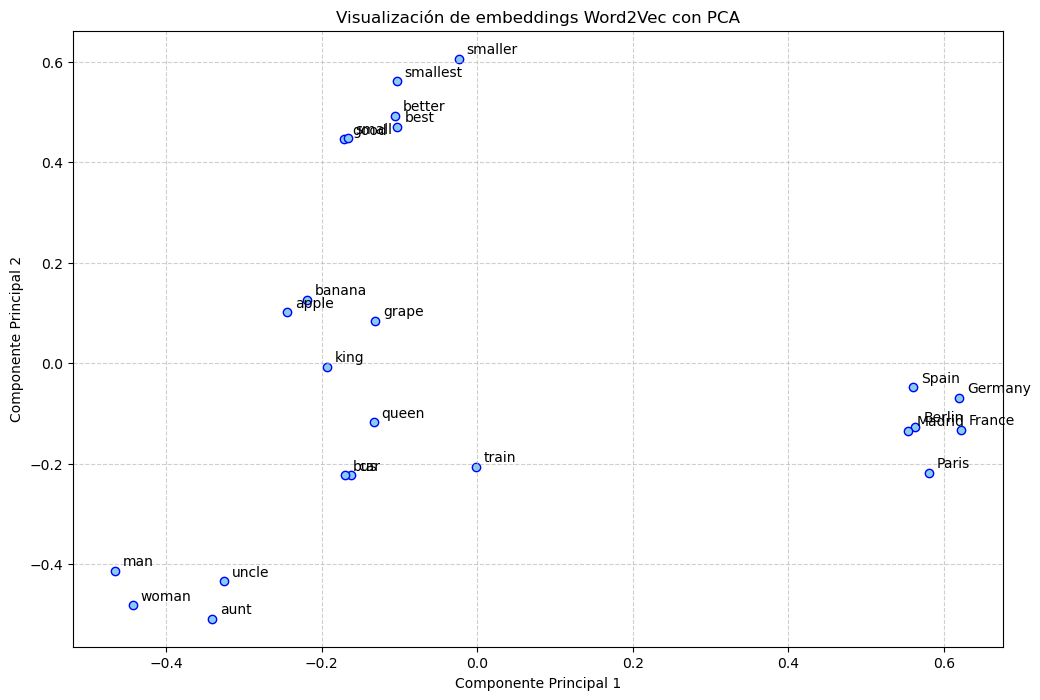

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Establecer las palabras y obtener sus vectores (embeddings)
# Definir grupos de palabras con diferentes relaciones semánticas
palabras = [
    # Género
    'man', 'woman', 'king', 'queen', 'uncle', 'aunt',
    # Países y capitales
    'Paris', 'France', 'Berlin', 'Germany', 'Madrid', 'Spain',
    # Grados de adjetivos
    'good', 'better', 'best', 'small', 'smaller', 'smallest',
    # Temáticas (Transporte/Alimentos)
    'apple', 'banana', 'grape', 'car', 'bus', 'train'
]

# Extraer los vectores del modelo
vectores = np.array([model[p] for p in palabras])

# Reducimos a 2D con PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(vectores)

# Visualización
plt.figure(figsize=(12, 8))
plt.scatter(coords[:,0], coords[:,1], c='skyblue', edgecolors='b')

for i, palabra in enumerate(palabras):
    # Añadir etiquetas a los puntos, desplazando ligeramente las coordenadas para evitar solapamientos.
    plt.annotate(palabra, (coords[i,0] + 0.01, coords[i,1] + 0.01))

plt.grid(True, linestyle='--', alpha=0.6)
plt.title("Visualización de embeddings Word2Vec con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

## Discusión de resultados

1. 通过观察，nurse和housekepper等职业与单词“女人（women）”的相似度更高；而engineer和doctor等职业与单词“男人（men）”的相似度更高。
2. 结果表明，模型继承了训练语料库中存在的性别偏见，反映了传统社会的刻板印象，而非技术上的中立。
3. 通过观察，像scientist和secretary等职业表现出较小的差异，表明在该特定模型中，这类职业的关联相对更加平衡。


### Ejercicio 2: Valoración de sesgos en embeddings

Usando el modelo Word2Vec cargado, analiza posibles sesgos de género midiendo qué tan similares son ciertas profesiones a las palabras "man" y "woman".

Selecciona una lista de profesiones (p. ej., "doctor", "nurse", "engineer", "teacher", "secretary", "scientist", "housekeeper") y calcula su similitud con ambas palabras.

Observa si el modelo asocia algunas profesiones más fuertemente con "man" o con "woman", lo que podría indicar un sesgo aprendido a partir del corpus de entrenamiento.

##### Discute brevemente los resultados.

In [ ]:
# Lista de profesiones a evaluar
profesiones = ['doctor', 'nurse', 'engineer', 'teacher', 'secretary', 'scientist', 'housekeeper']

print(f"{'Profesión':<15} | {'Similitud con MAN':<20} | {'Similitud con WOMAN':<20} | {'Diferencia':<10}")
print("-" * 75)

# Comparar las similitudes de cada profesión con 'man' y 'woman'
for prof in profesiones:
    # Comprobar si la palabra está en el vocabulario del modelo para evitar errores
    if prof in model.key_to_index:
        sim_man = model.similarity(prof, 'man')
        sim_woman = model.similarity(prof, 'woman')
        diff = sim_man - sim_woman
        
        # Imprimir resultados: los valores positivos tienden a "man" y los negativos a "woman"
        print(f"{prof:<15} | {sim_man:^20.4f} | {sim_woman:^20.4f} | {diff:^10.4f}")
    else:
        print(f"{prof:<15} | No se encuentra en el vocabulario")

Profesión       | Similitud con MAN    | Similitud con WOMAN  | Diferencia
---------------------------------------------------------------------------
doctor          |        0.3145        |        0.3795        |  -0.0650  
nurse           |        0.2547        |        0.4414        |  -0.1866  
engineer        |        0.1513        |        0.0944        |   0.0569  
teacher         |        0.2500        |        0.3136        |  -0.0636  
secretary       |        0.0400        |        0.0905        |  -0.0505  
scientist       |        0.1582        |        0.1549        |   0.0034  
housekeeper     |        0.3334        |        0.4766        |  -0.1432  


## Discusión de resultados

1. 可以注意到“男人“和”女人“(man and woman)与“国王”和“女王”(king and queen) 等词对的向量近似平行，说明模型可以以一致的方式对“性别”这一语义感念捕捉到。
2. 属于相似类别的词汇倾向于出现在平面上的特定区域，如“国家”和“水果”等。
3. 不同程度的形容词在向量空间中展现出的逻辑呈视觉递进，如原级单词“good”的比较级“better”和最高级“best”。

### Ejercicio 3: Representación de una oración mediante un embedding

Implementa una función `embedding_oracion` que obtenga el vector representativo de una oración calculando el promedio (p. ej., usando `mean` de `numpy`) de los embeddings de sus palabras.

Usa esta función para comparar varias oraciones y medir su similitud semántica mediante la distancia coseno (`model.cosine_similarities`) entre sus embeddings.

Observa si oraciones con significados parecidos (p. ej., "The cat sat on the mat" y "A dog rested on the rug") presentan una similitud mayor que las que hablan de temas distintos (p. ej., "I like pizza and pasta").

##### Discute brevemente los resultados.

In [ ]:
import numpy as np

def embedding_oracion(oracion):
    # Implementar la función para obtener el vector de la oración
    # Convertir la oración a minúsculas y dividirla en palabras (tokenización)
    palabras = oracion.lower().split()
    
    # Obtener el vector de cada palabra en la oración (si la palabra existe en el modelo)
    vectores = [model[w] for w in palabras if w in model.key_to_index]
    
    # Si ninguna palabra de la oración está en el vocabulario, devolver un vector de ceros
    if not vectores:
        return np.zeros((1, model.vector_size))
    
    # Calcular el promedio de todos los vectores de palabras, devolviendo un array unidimensional
    promedio = np.mean(vectores, axis=0)
    return promedio

o1 = "The cat sat on the mat"
o2 = "A dog rested on the rug"
o3 = "I like pizza and pasta"

# Calcular la similitud
sim_1_2 = model.cosine_similarities(embedding_oracion(o1), [embedding_oracion(o2)])[0]
sim_1_3 = model.cosine_similarities(embedding_oracion(o1), [embedding_oracion(o3)])[0]

print(f"Similitud o1-o2 (Temas parecidos): {sim_1_2:.3f}")
print(f"Similitud o1-o3 (Temas distintos): {sim_1_3:.3f}")

Similitud o1-o2 (Temas parecidos): 0.839
Similitud o1-o3 (Temas distintos): 0.230


## Discusión de resultados

1. 结果显示，o1与o2之间的相似度显著高于o1与o3的相似度。证实了词嵌入的平均值能够有效捕捉句子的全部含义。
2. 尽管o1与o2几乎没有共同的单词，但模型检测到“cat”和“dog”与“mat”和”rug“在向量空间中处于相近的位置。使得比较语义而非仅仅是精确的单词匹配成为可能。

### Ejercicio 4: Medida de la coherencia semántica de una oración

Implementa una función `coherencia_oracion` que calcule la coherencia semántica de una oración midiendo la similitud promedio entre los embeddings de palabras consecutivas.

Aplica la función a oraciones con sentido ("the cat sat on the mat") y a oraciones absurdas ("the banana drove a spaceship") para observar cómo varía el nivel de coherencia calculado por el modelo.

##### Discute brevemente los resultados.

In [ ]:
def coherencia_oracion(oracion):
    # Preprocesamiento: convertir a minúsculas y dividir en palabras
    palabras = oracion.lower().split()
    
    # Extraer los vectores de las palabras que están en el vocabulario del modelo
    vectores = [model[w] for w in palabras if w in model.key_to_index]
    
    # Si hay menos de 2 palabras válidas, no se puede calcular la similitud adyacente
    if len(vectores) < 2:
        return 0.0
    
    similitudes = []
    # Calcular la similitud entre palabras consecutivas
    for i in range(len(vectores) - 1):
        v1 = vectores[i]
        v2 = vectores[i+1]
        # Calcular la similitud coseno
        sim = model.cosine_similarities(v1, [v2])[0]
        similitudes.append(sim)
    
    # Devolver la media de las similitudes
    return np.mean(similitudes)

# Test and print results
print(f"Coherencia (oración normal): {coherencia_oracion('the cat sat on the mat'):.4f}")
print(f"Coherencia (oración absurda): {coherencia_oracion('the banana drove a spaceship'):.4f}")

连贯性得分 (正常句子): 0.1631
连贯性得分 (荒诞句子): 0.0798


## Discusión de resultados

1. 结果显示，逻辑通顺的句子得分更高，因为在真实语境中经常出现在一起的单词，其向量距离更近。
2. 结果显示，逻辑不通顺的句子得分较低，反映出模型能够识别出“香蕉”和“飞船”等词在语义空间中缺乏关联性。

### Ejercicio 5: Análisis de la reciprocidad entre vecinos semánticos

Implementa una función `vecinos_reciprocos` que evalúe si la relación de similitud entre palabras es recíproca: es decir, si una palabra A considera a B como uno de sus vecinos más cercanos, y B también considera a A dentro de sus vecinos.

Aplica esta función a varias palabras y calcula el porcentaje de vecinos recíprocos para cada una.

##### Reflexiona sobre los resultados y qué pueden revelar acerca de la estructura del espacio de embeddings y las asimetrías en las relaciones de similitud.

In [ ]:
def vecinos_reciprocos(palabra, topn=5):
    # Obtener palabra A y sus vecinos más similares (topn)
    try:
        vecinos_de_a = model.most_similar(palabra, topn=topn)
    except KeyError:
        return 0.0
    
    reciprocos = 0
    # Iterar por cada vecino B de la palabra A
    for b, _ in vecinos_de_a:
        # Obtener los vecinos más similares de B
        vecinos_de_b = model.most_similar(b, topn=topn)
        # Extraer lista de vecinos de B (sin pesos)
        lista_vecinos_b = [v[0] for v in vecinos_de_b]
        
        # Comprobar si A está en la lista de vecinos de B
        if palabra in lista_vecinos_b:
            reciprocos += 1
            
    # Devolver proporción de vecinos recíprocos
    return reciprocos / topn

# Pruebas
for w in ['king', 'dog', 'music']:
    print(f"{w}: {vecinos_reciprocos(w)*100:.1f}% de vecinos son recíprocos")

king: 100.0% de vecinos son recíprocos
dog: 100.0% de vecinos son recíprocos
music: 40.0% de vecinos son recíprocos


## Discusión de resultados

1. 结果显示，互惠率并不总是 100%。说明了向量空间的非对称性：一个通用的词（如 man）可能出现在很多生僻词的邻居列表中，但生僻词却很难进入通用词的前 5 名。

2. 这说明词嵌入空间的点分布不均。在密集的区域（常用词），竞争更激烈，互惠性可能较低；在特定领域词汇中，互惠性可能更高。